## 0. Setting up

### Importing libraries and defining constants

In [1]:
# Computing and visualisation libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn libraries for Naive Bayes, encoding, and evaluation
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay

)

# For splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Gaussian PDF
from scipy.stats import norm

# To normalise combined log-posteriors
from scipy.special import logsumexp

# Column names and LABEL_COL variable
CONTINUOUS = ['age', 'education-num', 'capital-gain',
              'capital-loss', 'hours-per-week']
 
CATEGORICAL = ['workclass', 'education', 'marital-status',
               'occupation', 'relationship', 'race',
               'sex', 'native-country']
 
LABEL_COL = 'income'

ALL_FEATURES = CONTINUOUS + CATEGORICAL

### Creating helper functions

In [2]:
def load_data(path, has_labels=True):
    """ 
    Load data from a CSV into a pandas DataFrame and perform preprocessing steps.

    Steps:
    1. Load data and store in a pandas DataFrame.
    2. Drop the 'fnlwgt' column.
    3. Drop rows with any missing values.
    4. Convert LABEL_COL variable to binary labels (1 for '>50K', 0 for '<=50K').
    """

    # Step 1
    df = pd.read_csv(path) 

    # Step 2
    if 'fnlwgt' in df.columns:
        df.drop(columns=['fnlwgt'], inplace=True) 
    
    # Step 3
    df = df.dropna(subset=ALL_FEATURES)

    # Step 4
    if has_labels:
        df[LABEL_COL] = df[LABEL_COL].apply(lambda x: 1 if x == '>50K' else 0)
    
    return df

def fit_mixed_nb(data):
    """
    Train the mixed Naive Bayes model on a labelled DataFrame.

    GaussianNB and  CategoricalNB can't be merged into a single model, so they
    are trained separately and combined using log-likelihoods.

    Setting unknown_vaolue = -1 so I can catch unseen categories later
    """
    y = data[LABEL_COL].values

    # Gaussian
    x_num = data[CONTINUOUS].values
    nb_gauss = GaussianNB()
    nb_gauss.fit(x_num, y)

    # Categorical 
    # Fit encoder on the raw strings and flagging unknowns as -1
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    x_cat_enc = enc.fit_transform(data[CATEGORICAL])

    # min_categories guarantees the probability matrix has a column for every
    # known value even if a particular class never observed it in training
    n_vals_per_feat = [len(grp) for grp in enc.categories_]
    nb_cat = CategoricalNB(alpha=1.0, min_categories=n_vals_per_feat)
    nb_cat.fit(x_cat_enc, y)

    # Build a lookup: feature name → array of known string values
    vocab = {feat: enc.categories_[idx] for idx, feat in enumerate(CATEGORICAL)}

    return nb_gauss, nb_cat, enc, vocab

def score_instances(nb_gauss, nb_cat, enc, frame):
    """Return predicted labels and normalised log-posteriors for every row
    in frame, combining the Gaussian and categorical sub-models.
    """
    x_num = frame[CONTINUOUS].values
    x_cat = enc.transform(frame[CATEGORICAL])   # -1 marks OOV positions

    n_cls = len(nb_gauss.classes_)

    # Start from the Gaussian joint log-likelihood
    running_log_post = nb_gauss.predict_log_proba(x_num).copy()

    # Add the categorical joint log-likelihood, then remove the extra prior
    log_prior = np.log(nb_gauss.class_prior_)
    cat_contribution = nb_cat._joint_log_likelihood(
        np.clip(x_cat, 0, None).astype(int)   # clip so -1 doesn't index out of bounds
    )
    running_log_post = running_log_post + cat_contribution - log_prior

    # Fix every column that had at least one OOV entry
    alpha = nb_cat.alpha
    for feat_idx, feat_name in enumerate(CATEGORICAL):
        n_known = len(enc.categories_[feat_idx])
        col_codes = x_cat[:, feat_idx].astype(int)
        is_oov = (col_codes == -1)

        if not is_oov.any():
            continue 

        # Fix OOV entries one by one
        oov_log_prob = np.log(alpha) - np.log(
            nb_cat.class_count_ + alpha * n_known
        )

        # Replace the incorrect placeholder with the correct OOV log-probability for each class
        for cls_idx in range(n_cls):
            placeholder = nb_cat.feature_log_prob_[feat_idx][cls_idx, 0]
            running_log_post[is_oov, cls_idx] += (
                oov_log_prob[cls_idx] - placeholder
            )

    # Normalise so the two columns sum to 1 in log-space using logsumexp, otherwise resulting in division by 0 errors. 
    running_log_post -= logsumexp(running_log_post, axis=1, keepdims=True)

    labels = np.argmax(running_log_post, axis=1)
    return labels, running_log_post

def posterior_ratio(log_post):
    """
    Compute R = P(>50K|x) / P(<=50K|x) from log posteriors.
    """
    proba = np.exp(log_post)
    proba = np.clip(proba, 1e-300, None)
    return proba[:, 1] / proba[:, 0]


## 1. Supervised model training


In [3]:
# Load supervised training data and fit the mixed Naive Bayes model
train_df = load_data('data/adult_supervised_train.csv', has_labels=True)
nb_gauss_q1, nb_cat_q1, enc_q1, vocab_q1 = fit_mixed_nb(train_df)


# print(pd.read_csv("data/adult_supervised_train.csv").isna().sum())
# print("---")
# print((pd.read_csv("data/adult_supervised_train.csv")=='?').sum())


**Question 1.1** <br>
What are the prior probabilities of the two classes P(c) in the training data? Does the training set exhibit class imbalance, and if so, what effect might this hav on classifier behaviour?

Class distribution in training set:
P(c = '<=50K ') = 0.7541, (count=11369.0)
P(c = '>50K  ') = 0.2459, (count=3707.0)

Imbalance Ratio (<=50K : >50K) = 3.07 : 1
Majority class is '<=50K'.


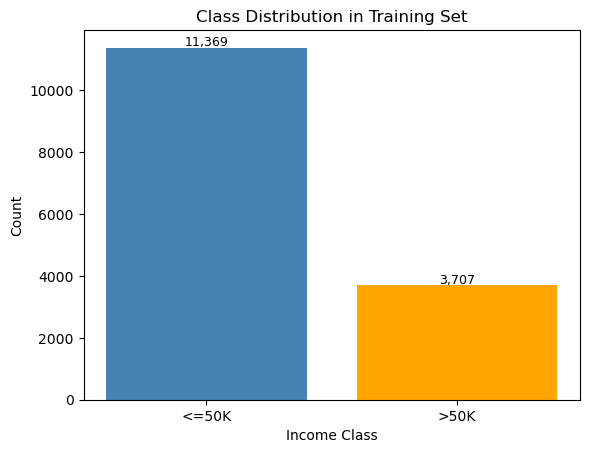

In [4]:
print("Class distribution in training set:")
for c, count, prior in zip(nb_gauss_q1.classes_, 
                           nb_gauss_q1.class_count_, 
                           nb_gauss_q1.class_prior_):
    label = '>50K' if c == 1 else '<=50K'
    print(f"P(c = '{label:6}') = {prior:.4f}, (count={count})")

# Calculate the ratio of the majority to the minority to identify imbalance.
imbalance_ratio = nb_gauss_q1.class_count_[0] / nb_gauss_q1.class_count_[1]
print(f"\nImbalance Ratio (<=50K : >50K) = {imbalance_ratio:.2f} : 1")

# Identify the majority class based on class counts.
print(f"Majority class is '{'>50K' if nb_gauss_q1.class_count_[1] > nb_gauss_q1.class_count_[0] else '<=50K'}'.")

# Plot the results
fig, ax = plt.subplots()
ax.bar(['<=50K', '>50K'], 
       nb_gauss_q1.class_count_,
       color=['steelblue', 'orange'] 
       )
ax.set_title('Class Distribution in Training Set')
ax.set_xlabel('Income Class')
ax.set_ylabel('Count')
for i, v in enumerate(nb_gauss_q1.class_count_):
    ax.text(i, v + 50, f'{int(v):,}', ha='center', fontsize=9)
plt.savefig('figures/fig_1.1_class_distribution.png', dpi=300)
plt.show()

**Question 1.2**<br>
For each continuous feature, report the estimated mean and standard deviation for each class. Which continuous features show the greatest seperation between classes? Do these seem intuitively reasonable given the nature of the feature?

       Feature  Mean (<=50K)  Std (<=50K)  Mean (>50K)   Std (>50K)  Separation (d)
 education-num      9.629255     2.447812    11.594551     2.364977        0.816697
           age     37.050752    13.711919    43.938495    10.302703        0.573629
hours-per-week     39.428622    11.910803    45.642298    10.396091        0.557108
  capital-gain    157.666022  1017.863238  3607.146749 13616.622967        0.471418
  capital-loss     55.974580   316.020139   202.362018   603.991020        0.318230


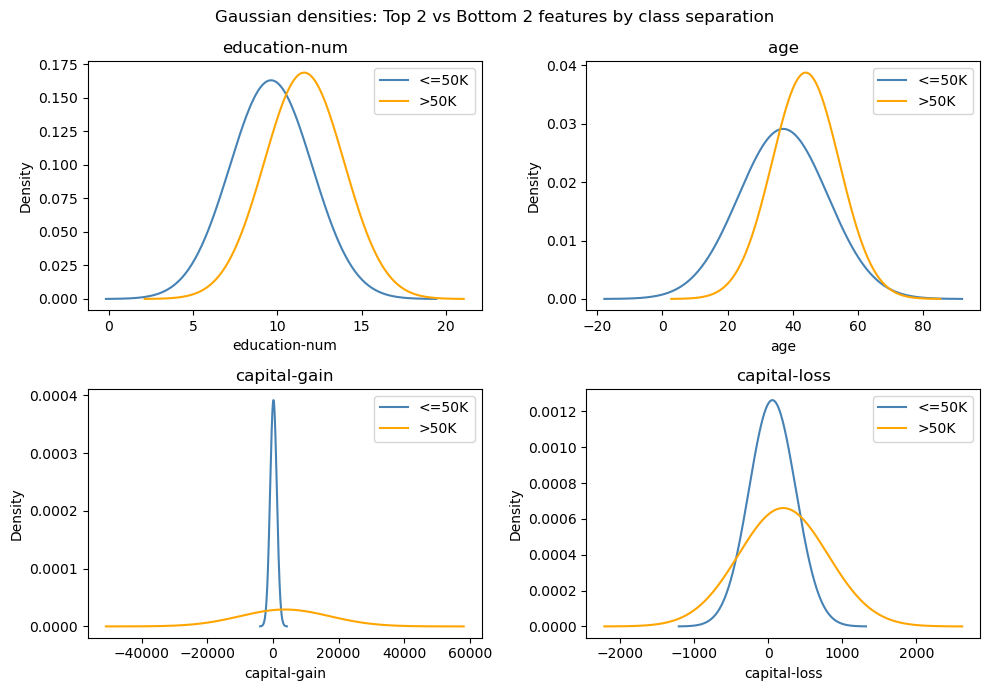

In [5]:
# Summary table of Gaussian parameters for each continuous feature. 
rows = []
for i, feat in enumerate(CONTINUOUS):
    mean0, std_low = nb_gauss_q1.theta_[0][i], np.sqrt(nb_gauss_q1.var_[0][i])
    mean1, std_high = nb_gauss_q1.theta_[1][i], np.sqrt(nb_gauss_q1.var_[1][i])
    average_std = (std_low + std_high) / 2
    seperation = abs(mean1 - mean0) / average_std if average_std > 0 else 0
    rows.append({
        'Feature': feat,
        'Mean (<=50K)': mean0, 'Std (<=50K)': std_low,
        'Mean (>50K)': mean1, 'Std (>50K)': std_high,
        'Separation (d)': seperation
    })

gauss_table = pd.DataFrame(rows).sort_values('Separation (d)', ascending=False)
print(gauss_table.to_string(index=False))

top2 = gauss_table.head(2)['Feature'].tolist()
bottom2 = gauss_table.tail(2)['Feature'].tolist()

features = top2 + bottom2

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, feat in zip(axes.flatten(), features):
    i = CONTINUOUS.index(feat)
    
    for c_idx, col, label in zip([0, 1], ['steelblue', 'orange'], ['<=50K', '>50K']):
        mu = nb_gauss_q1.theta_[c_idx, i]
        std = np.sqrt(nb_gauss_q1.var_[c_idx, i])
        x = np.linspace(mu - 4*std, mu + 4*std, 300)
        ax.plot(x, norm.pdf(x, mu, std), color=col, label=label)
    
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Gaussian densities: Top 2 vs Bottom 2 features by class separation')
plt.tight_layout()
plt.savefig('figures/fig_1.2_gaussian_densities_combined.png', dpi=300)
plt.show()

**Question 1.3**<br>

For each categorical feature, identify the category value most strongly predicteve of each class. One way to measure this is the probability ratio:<br>

$$
R = \frac{P(x_j = v \mid c_1)}{P(x_j = v \mid c_2)}
$$

List the five most predictive category values for each class (across all categorical features) and their R values. 


  Top 5 most predictive of >50K  (highest R):
       Feature             Value      R
     education       Prof-school 7.9587
     education         Doctorate 7.1354
marital-status Married-AF-spouse 4.2882
     education           Masters 3.5551
native-country            Taiwan 3.3832

  Top 5 most predictive of <=50K  (lowest R):
     Feature           Value      R
relationship       Own-child 0.0522
  occupation Priv-house-serv 0.0838
  occupation   Other-service 0.1354
relationship  Other-relative 0.1445
   education             9th 0.1508


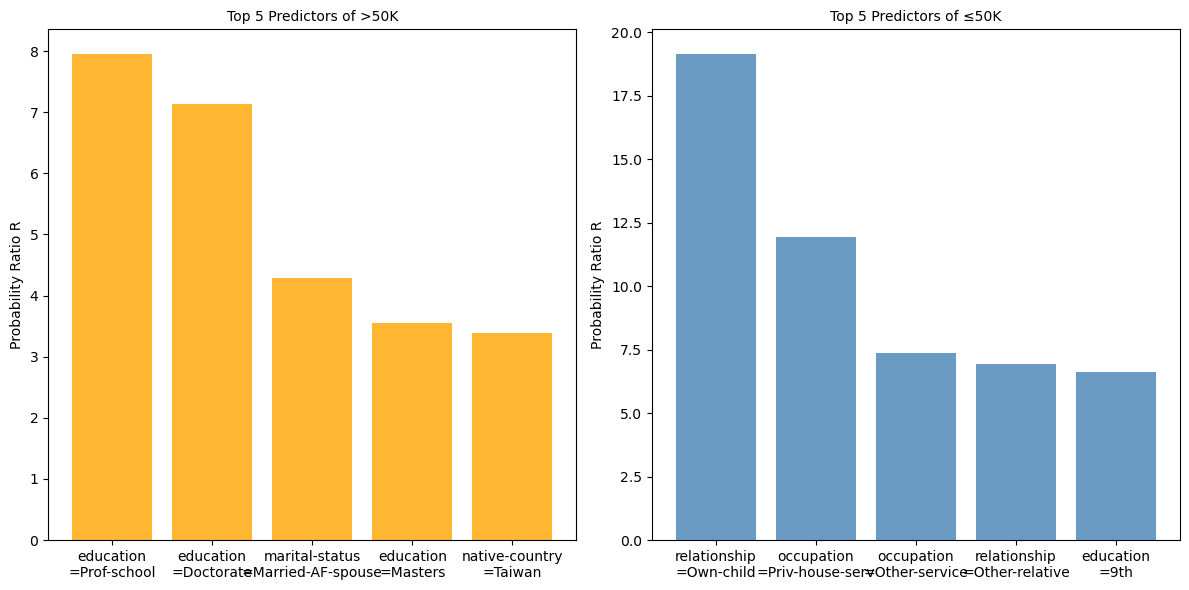

In [6]:
# R > 1 means the model thinks >50K is more likely, R < 1 means <=50K is more likely.
ratios = []

for i, feat in enumerate(CATEGORICAL):
    categories = enc_q1.categories_[i]
    feat_probs = nb_cat_q1.feature_log_prob_[i]
    lp_low = feat_probs[0, :] # <=50K
    lp_high = feat_probs[1, :] # >50K
    for j, v in enumerate(categories):
        ratios.append({'Feature': feat, 'Value': v, 'R': round(np.exp(lp_high[j] - lp_low[j]), 4)})
    
ratio_df = pd.DataFrame(ratios)

print('\n  Top 5 most predictive of >50K  (highest R):')
print(ratio_df.nlargest(5, 'R')[['Feature', 'Value', 'R']].to_string(index=False))

print('\n  Top 5 most predictive of <=50K  (lowest R):')
print(ratio_df.nsmallest(5, 'R')[['Feature', 'Value', 'R']].to_string(index=False))

# Bar chart of the top-10 predictors (5 per class) for easy visual comparison
top_high = ratio_df.nlargest(5, 'R').copy()
top_low  = ratio_df.nsmallest(5, 'R').copy()
top_low['R_display'] = 1.0 / top_low['R']    # flip so bars all go rightward

# Plot to compare the top predictors for each class side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, (df_plot, title, color) in enumerate([
    (top_high, 'Top 5 Predictors of >50K', 'orange'),
    (top_low, 'Top 5 Predictors of ≤50K', 'steelblue'),
]):
    ax = axes[i]
    labels = [f"{r['Feature']}\n={r['Value']}" for _, r in df_plot.iterrows()]
    values = df_plot['R'].values if '>50K' in title else top_low['R_display'].values

    ax.bar(labels, values, color=color, alpha=0.8)
    ax.set_ylabel('Probability Ratio R')
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig('figures/fig_1.3_ratio_bars_vertical.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Supervised model evaluation

In [7]:
# Load test data and generate predictions using supervised model
test_df = load_data('data/adult_test.csv', has_labels=True)
y_test = test_df[LABEL_COL].values

preds_q1, log_post_q1 = score_instances(nb_gauss_q1, nb_cat_q1, enc_q1, test_df)
R_vals_q1 = posterior_ratio(log_post_q1)


**Question 2.1**<br>
Report the overall accuracy of your classifier as well as a class-level breakdown. Include a confusion matric and report precision, recall, and F1-score for each class.

Overall Accuracy: 0.83072
Accuracy for '>50K': 0.52537
Accuracy for '<=50K': 0.93294
              precision    recall  f1-score   support

           0     0.8545    0.9329    0.8920     11303
           1     0.7240    0.5254    0.6089      3784

    accuracy                         0.8307     15087
   macro avg     0.7892    0.7292    0.7504     15087
weighted avg     0.8217    0.8307    0.8210     15087



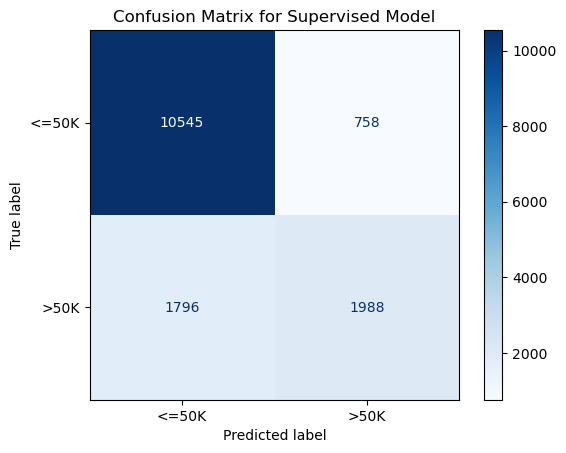

In [8]:
print(f"Overall Accuracy: {accuracy_score(y_test, preds_q1):.5f}")
print(f"Accuracy for '>50K': {accuracy_score(y_test[y_test == 1], preds_q1[y_test == 1]):.5f}")
print(f"Accuracy for '<=50K': {accuracy_score(y_test[y_test == 0], preds_q1[y_test == 0]):.5f}")

print(classification_report(y_test, preds_q1, digits=4))

fig, ax = plt.subplots()
ConfusionMatrixDisplay(
    confusion_matrix(y_test, preds_q1),
    display_labels=['<=50K', '>50K']
).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix for Supervised Model')
plt.savefig('figures/fig_1.3_confusion_matrix.png', dpi=300)
plt.show()


**Question 2.2**<br>
Out-of-vocabulary / unseen categories: some categorical feature values in the test set may not have appeard during training. Report how many test instances contain at least one unseen category value, and describe how your implementation handles them (e.g., via Laplace smoothing, or by skipping the feature entirely). Were any test instances skipped entirely because they could not be classified?

In [9]:
x_category_test = enc_q1.transform(test_df[CATEGORICAL])
oov_per_cell = (x_category_test == -1)
oov_per_row = oov_per_cell.any(axis=1)

print(f"Test instances with ≥1 OOV category: {oov_per_row.sum():,} ({100*oov_per_row.mean():.2f}%)")
print(f"Test instances with zero OOV: {(~oov_per_row).sum():,}")
print("\n")

# Breakdown by feature
if oov_per_cell.any():
    print("OOV counts per feature:")
    for i, feat in enumerate(CATEGORICAL):
        n = oov_per_cell[:, i].sum()
        if n > 0:
            print(f"  {feat}: {n} OOV instances")
else:
    print("No OOV categories found in test set.")

Test instances with ≥1 OOV category: 1 (0.01%)
Test instances with zero OOV: 15,086


OOV counts per feature:
  native-country: 1 OOV instances


**Q2.3**<br>
Provide examples of instances classified with high and low confidence. The confidence of a prediction can be measured using the posterior ratio:<br>
$$
R = \frac{P(c_1 \mid x)}{P(c_2 \mid x)}
$$



High-confidence >50K predictions (largest R)
      age    education       occupation  capital-gain  hours-per-week      marital-status  true  pred              R
142    50  Prof-school   Prof-specialty         99999              80  Married-civ-spouse     1     1  1.000000e+300
460    41    Doctorate   Prof-specialty         99999              70  Married-civ-spouse     1     1  1.000000e+300
1050   47      Masters  Exec-managerial         99999              50  Married-civ-spouse     1     1  1.000000e+300


High-confidence <=50K predictions (smallest R)
       age education     occupation  capital-gain  hours-per-week marital-status  true  pred             R
13228   18      10th  Other-service             0               3  Never-married     0     0  9.242193e-10
3216    17      10th  Other-service             0              12  Never-married     0     0  1.074523e-09
10584   17      11th  Other-service             0               5  Never-married     0     0  1.107104e-09


Near dec

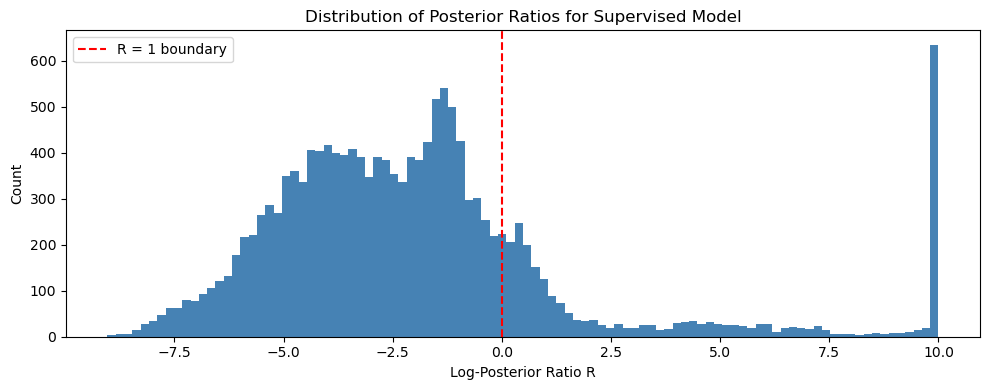

In [10]:
# Build a results frame so we can slice by predicted label and sort by confidence
result_df = test_df[ALL_FEATURES].copy()
result_df['true']   = y_test
result_df['pred']   = preds_q1
result_df['R']      = R_vals_q1

# Define specific columns
report_cols = ['age', 'education', 'occupation', 'capital-gain', 'hours-per-week', 'marital-status', 'true', 'pred', 'R']

def print_examples(df, label):
    print(label)
    print(df[report_cols].to_string(index=True))
    print("\n")

# High confidence >50K  (largest R)
print_examples(
    result_df[result_df['pred'] == 1].nlargest(3, 'R'),
    "High-confidence >50K predictions (largest R)"
)
# High confidence <=50K (smallest R)
print_examples(
    result_df[result_df['pred'] == 0].nsmallest(3, 'R'),
    "High-confidence <=50K predictions (smallest R)"
)
# Near decision boundary (R closest to 1)
boundary_idx = (result_df['R'] - 1.0).abs().nsmallest(3).index
print_examples(result_df.loc[boundary_idx], "Near decision boundary (R ≈ 1)")

fig, ax = plt.subplots(figsize=(10, 4))
R_log = np.log10(np.clip(R_vals_q1, 1e-10, 1e10))
ax.hist(R_log, bins=100, color='steelblue')
ax.axvline(0, color='red', linestyle='--', label='R = 1 boundary')
ax.set_xlabel('Log-Posterior Ratio R')
ax.set_ylabel('Count')
ax.set_title('Distribution of Posterior Ratios for Supervised Model')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_2.3_posterior_ratio_hist_q1.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Extending the model with semi-supervised training

## Option 1: Label Propagation

Use your Q1 model to assign predicted labels to the unlabelled dataset. Treat these predictions as ground truth, then retrain your model on the combined supervised data and pseudo-labelled data.

Consider these extensions to improve the basic approach:

- Is it better to use all unlabelled data, or only instances labelled with high confidence by the Q1 model?

- Does iterative label propagation help? For example: label 50% of the unlabelled data with the Q1 model, retrain, then use the new model to label the remaining 50%, and train a final model on all available data.

In [11]:
# Load unlabelled data (no income column)
unlabelled_df = load_data('data/adult_unlabelled.csv', has_labels=False)

# Create a 80/20 validation split from the supervised training data.
# The validation set is only used for picking the threshold.
train_sub, val_sub = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df[LABEL_COL]
)
val_y = val_sub[LABEL_COL].values

In [12]:
def one_shot_propagation(sup_df, unlab_df, r_threshold):

    gnb1, cnb1, enc1, _ = fit_mixed_nb(sup_df)
    _, lp_unlab = score_instances(gnb1, cnb1, enc1, unlab_df)
    R_unlab = posterior_ratio(lp_unlab)
    pred_unlab = np.argmax(lp_unlab, axis=1)

    # Keep only high-confidence pseudo-labels
    keep = (R_unlab > r_threshold) | (R_unlab < 1.0 / r_threshold)
    pseudo_df = unlab_df[ALL_FEATURES][keep].copy()
    pseudo_df[LABEL_COL] = pred_unlab[keep]

    combined_df = pd.concat([sup_df, pseudo_df], ignore_index=True)
    gnb2, cnb2, enc2, _ = fit_mixed_nb(combined_df)

    return gnb2, cnb2, enc2, combined_df, keep.sum(), pseudo_df, R_unlab, keep

def run_iterative_propagation(sup_df, unlab_df, r_threshold, split_fraction=0.5):
    shuffled = unlab_df.sample(frac=1, random_state=42).reset_index(drop=True)
    split_idx = int(len(shuffled) * split_fraction)
    half1 = shuffled.iloc[:split_idx].copy()
    half2 = shuffled.iloc[split_idx:].copy()

    # Stage 1
    g1, c1, e1, _ = fit_mixed_nb(sup_df)
    pred1, lp1 = score_instances(g1, c1, e1, half1)
    R1 = posterior_ratio(lp1)
    mask1 = (R1 > r_threshold) | (R1 < 1.0 / r_threshold)
    ps1 = half1[ALL_FEATURES][mask1].copy()
    ps1[LABEL_COL] = pred1[mask1]

    # Stage 2
    # Retrain on labelled + stage 1 pseudo-labels then score the second half
    aug_df2 = pd.concat([sup_df, ps1], ignore_index=True)
    g2, c2, e2, _ = fit_mixed_nb(aug_df2)
    pred2, lp2 = score_instances(g2, c2, e2, half2)
    R2 = posterior_ratio(lp2)
    mask2 = (R2 > r_threshold) | (R2 < 1.0 / r_threshold)
    ps2 = half2[ALL_FEATURES][mask2].copy()
    ps2[LABEL_COL] = pred2[mask2]

    # Final model
    final_df = pd.concat([sup_df, ps1, ps2], ignore_index=True)
    gf, cf, ef, _ = fit_mixed_nb(final_df)

    return gf, cf, ef, final_df, mask1.sum() + mask2.sum(), mask1.sum(), mask2.sum()

In [13]:
# Evaluate thresholds on the validation split
thresholds = [1.5, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 99.0, 999.0]
threshold_results = []

print(f"{'Threshold':>10} {'n_kepteudo':>10} {'val_acc':>10}  type")

for t in thresholds:

    # One-shot label propagation
    g, c, e, _, n_kept, ps_df, R_unlab_t, cmask = one_shot_propagation(
        train_sub, unlabelled_df, t
    )
    yv, _ = score_instances(g, c, e, val_sub)
    acc_1  = accuracy_score(val_y, yv)

    # Iterative label propagation
    gi, ci, ei, _, n_iter, _, _ = run_iterative_propagation(train_sub, unlabelled_df, t)
    yv_i, _ = score_instances(gi, ci, ei, val_sub)
    acc_i   = accuracy_score(val_y, yv_i)

    threshold_results.append({
        'threshold': t, 'n_kepteudo': n_kept,
        'val_acc_oneshot': round(acc_1, 4), 'val_acc_iterative': round(acc_i, 4)
    })
    print(f"{t:>12.1f} {n_kept:>10,} {acc_1:>10.4f}  one-shot")
    print(f"{t:>12.1f} {n_iter:>10,} {acc_i:>10.4f}  iterative")

 Threshold n_kepteudo    val_acc  type
         1.5     14,632     0.8067  one-shot
         1.5     14,668     0.8047  iterative
         2.0     14,355     0.8067  one-shot
         2.0     14,411     0.8050  iterative
         3.0     13,880     0.8070  one-shot
         3.0     14,023     0.8050  iterative
         5.0     13,288     0.8064  one-shot
         5.0     13,530     0.8054  iterative
        10.0     12,460     0.8060  one-shot
        10.0     12,854     0.8057  iterative
        20.0     11,482     0.8107  one-shot
        20.0     11,990     0.8054  iterative
        50.0     10,332     0.8176  one-shot
        50.0     10,737     0.8130  iterative
        99.0      9,615     0.8206  one-shot
        99.0      9,953     0.8173  iterative
       999.0      7,536     0.8200  one-shot
       999.0      7,869     0.8193  iterative


Best one-shot  threshold: 99.0, val_acc = 0.8206
Best iterative threshold: 99.0,val_acc = 0.8173


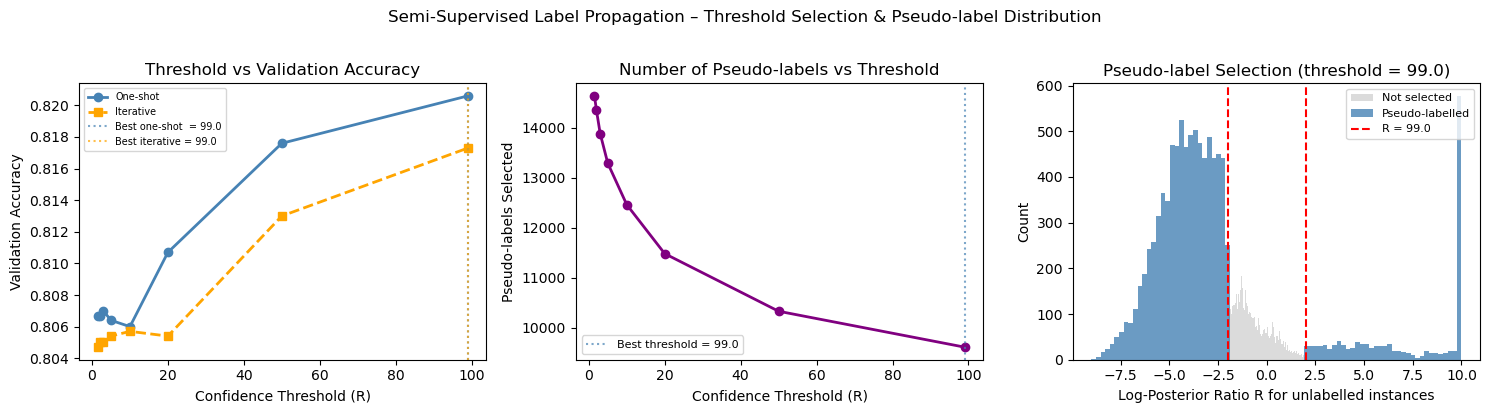


Pseudo-label class counts at threshold=99.0:
income
<=50K    8248
>50K     1367
Name: count, dtype: int64


In [14]:
# Excluding the last row which has a lower accuracy and would make the scale of the plots less informative
thr_df = pd.DataFrame(threshold_results[:-1])

# Select best thresholds based on validation accuracy for each approach
best_row_os  = thr_df.loc[thr_df['val_acc_oneshot'].idxmax()]
best_row_it  = thr_df.loc[thr_df['val_acc_iterative'].idxmax()]
best_t_os    = best_row_os['threshold']
best_t_it    = best_row_it['threshold']

print(f"Best one-shot  threshold: {best_t_os}, val_acc = {best_row_os['val_acc_oneshot']:.4f}")
print(f"Best iterative threshold: {best_t_it},val_acc = {best_row_it['val_acc_iterative']:.4f}")

# Re-run the label propagation with the best threshold to grab data for the plots
_, _, _, _, n_best, pseudo_df_best, R_unlab_best, cmask_best = one_shot_propagation(
    train_sub, unlabelled_df, best_t_os
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Graph 1: Validation accuracy vs threshold (one-shot vs iterative)
ax = axes[0]
ax.plot(thr_df['threshold'], thr_df['val_acc_oneshot'], marker='o', color='steelblue',
        linewidth=2, label='One-shot')
ax.plot(thr_df['threshold'], thr_df['val_acc_iterative'], marker='s', color='orange',
        linewidth=2, linestyle='--', label='Iterative')
ax.axvline(best_t_os, color='steelblue', linestyle=':', alpha=0.7,
           label=f'Best one-shot  = {best_t_os}')
ax.axvline(best_t_it, color='orange',    linestyle=':', alpha=0.7,
           label=f'Best iterative = {best_t_it}')
ax.set_xlabel('Confidence Threshold (R)')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Threshold vs Validation Accuracy')
ax.legend(fontsize=7)

# Graph 2: # pseudo-labels selected vs threshold
ax2 = axes[1]
ax2.plot(thr_df['threshold'], thr_df['n_kepteudo'], marker='o', color='purple', linewidth=2)
ax2.axvline(best_t_os, color='steelblue', linestyle=':', alpha=0.7,
            label=f'Best threshold = {best_t_os}')
ax2.set_xlabel('Confidence Threshold (R)')
ax2.set_ylabel('Pseudo-labels Selected')
ax2.set_title('Number of Pseudo-labels vs Threshold')
ax2.legend(fontsize=8)

# Graph 3: Distribution of R values in the unlabelled set
ax3 = axes[2]
R_log_all      = np.log10(np.clip(R_unlab_best, 1e-10, 1e10))
R_log_selected = R_log_all[cmask_best]
R_log_rejected = R_log_all[~cmask_best]

ax3.hist(R_log_rejected, bins=80, color='lightgrey',   alpha=0.8, label='Not selected')
ax3.hist(R_log_selected, bins=80, color='steelblue',   alpha=0.8, label='Pseudo-labelled')
thresh_log = np.log10(best_t_os)
ax3.axvline( thresh_log, color='red', linestyle='--', label=f'R = {best_t_os}')
ax3.axvline(-thresh_log, color='red', linestyle='--')
ax3.set_xlabel('Log-Posterior Ratio R for unlabelled instances')
ax3.set_ylabel('Count')
ax3.set_title(f'Pseudo-label Selection (threshold = {best_t_os})')
ax3.legend(fontsize=8)

plt.suptitle('Semi-Supervised Label Propagation – Threshold Selection & Pseudo-label Distribution', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_3.1_threshold_selection.png', dpi=200, bbox_inches='tight')
plt.show()

# Class balance of selected pseudo-labels where grey bars = discarded and blue bars = selected
print(f"\nPseudo-label class counts at threshold={best_t_os}:")
print(pseudo_df_best[LABEL_COL].value_counts().rename({0: '<=50K', 1: '>50K'}))

In [15]:
# Retrain on the entire supervised set using the best threshold and report the final class balance of the pseudo-labelled instances that were added.
nb_gauss_q3, nb_cat_q3, enc_q3, combined_df_q3, n_kept, pseudo_final, _, _ = \
    one_shot_propagation(train_df, unlabelled_df, best_t_os)

print(f"Supervised training instances: {len(train_df):,}")
print(f"Pseudo-labelled instances added: {n_kept:,}")
print(f"Combined training set: {len(combined_df_q3):,}")
print(f"\nPseudo-label class distribution:")
print(pseudo_final[LABEL_COL].value_counts().rename({0: '<=50K', 1: '>50K'}))

Supervised training instances: 15,076
Pseudo-labelled instances added: 9,676
Combined training set: 24,752

Pseudo-label class distribution:
income
<=50K    8289
>50K     1387
Name: count, dtype: int64


## 4. Supervised model evaluation

In [16]:
# Generate predictions for both models on the held-out test set
test_df = load_data('data/adult_test.csv', has_labels=True)
y_test  = test_df[LABEL_COL].values

preds_q1, log_post_q1 = score_instances(nb_gauss_q1, nb_cat_q1, enc_q1, test_df)
y_pred_q3, log_post_q3 = score_instances(nb_gauss_q3, nb_cat_q3, enc_q3, test_df)

R_vals_q1 = posterior_ratio(log_post_q1)
R_vals_q3 = posterior_ratio(log_post_q3)

**Question 4.1**<br>
How does the performance of your semi-supervised model (Q3) compare to your supervised model (Q1)? Report accuracy, precision, recall, and F1-score for both models on the test set, and discuss whether the improvement (or lack thereof) was expected.

In [17]:
# Print classification reports for both models
for label, preds in [('Supervised', preds_q1), ('Semi-supervised', y_pred_q3)]:
    print(f"{label}")
    print(f"Overall accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds, target_names=['<=50K', '>50K'], digits=4))

Supervised
Overall accuracy: 0.8307
              precision    recall  f1-score   support

       <=50K     0.8545    0.9329    0.8920     11303
        >50K     0.7240    0.5254    0.6089      3784

    accuracy                         0.8307     15087
   macro avg     0.7892    0.7292    0.7504     15087
weighted avg     0.8217    0.8307    0.8210     15087

Semi-supervised
Overall accuracy: 0.8190
              precision    recall  f1-score   support

       <=50K     0.8462    0.9269    0.8847     11303
        >50K     0.6948    0.4968    0.5794      3784

    accuracy                         0.8190     15087
   macro avg     0.7705    0.7119    0.7320     15087
weighted avg     0.8082    0.8190    0.8081     15087



**Question 4.2**<br>
How has the model changed after semi-supervised training?

Investigate changes in:

a. **Model confidence** — has the distribution of posterior ratios *R* shifted?

b. **Feature parameters** — have the estimated means/variances (continuous) or category probabilities (categorical) changed meaningfully?

c. **Most predictive features** — have the top predictors for each class changed?

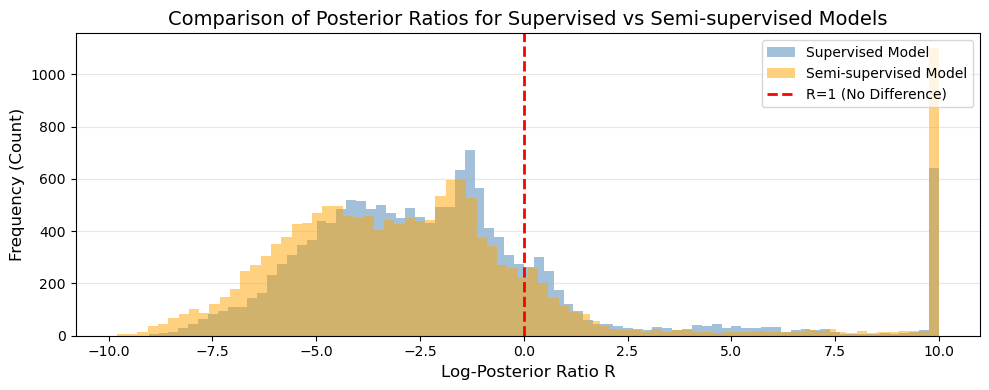

Q1: median posterior = -2.429, confidence = 83.3%
Q3: median posterior = -2.799, confidence = 87.2%


In [18]:
plt.figure(figsize=(10, 4))

for R_vals, tag, colour in [
    (R_vals_q1, 'Supervised Model', 'steelblue'),
    (R_vals_q3, 'Semi-supervised Model', 'orange'),
]:
    log_R = np.log10(np.clip(R_vals, 1e-10, 1e10))
    plt.hist(log_R, bins=80, color=colour, alpha=0.5, label=tag, density=False)

# The red dashed line is R = 1, which is the decision boundary where the model is equally confident in both classes.
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='R=1 (No Difference)')

plt.title('Comparison of Posterior Ratios for Supervised vs Semi-supervised Models', fontsize=14)
plt.xlabel('Log-Posterior Ratio R', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/fig_4.2_combined_posterior_ratios.png', dpi=300)
plt.show()

# Summary statistics
for tag, R_vals in [('Q1', R_vals_q1), ('Q3', R_vals_q3)]:
    log_R = np.log10(np.clip(R_vals, 1e-10, 1e10))
    pct_conf = (np.abs(log_R) > 1).mean() * 100
    print(f"{tag}: median posterior = {np.median(log_R):.3f}, confidence = {pct_conf:.1f}%")




In [19]:
# Compare Gaussian parameters for each continuous feature between 
# the supervised and semi-supervised models to see how they 
# changed after adding pseudo-labelled data.
parameter_rows = []
for i, feat in enumerate(CONTINUOUS):
    for c_idx, label in [(0, '<=50K'), (1, '>50K')]:
        parameter_rows.append({
            'Feature': feat,
            'Class': label,
            'Mean Q1': round(nb_gauss_q1.theta_[c_idx][i], 3),
            'Mean Q3': round(nb_gauss_q3.theta_[c_idx][i], 3),
            'Delta Mean':   round(nb_gauss_q3.theta_[c_idx, i] - nb_gauss_q1.theta_[c_idx, i], 3),
            'Std Q1': round(np.sqrt(nb_gauss_q1.var_[c_idx][i]), 3),
            'Std Q3': round(np.sqrt(nb_gauss_q3.var_[c_idx][i]), 3),
            'Delta Std':    round(np.sqrt(nb_gauss_q3.var_[c_idx, i]) - np.sqrt(nb_gauss_q1.var_[c_idx, i]), 3)
        })

parameter_df = pd.DataFrame(parameter_rows)
print(parameter_df.to_string(index=False))

       Feature Class  Mean Q1  Mean Q3  Delta Mean    Std Q1    Std Q3  Delta Std
           age <=50K   37.051   36.054      -0.997    13.712    13.767      0.055
           age  >50K   43.938   44.089       0.151    10.303    10.562      0.259
 education-num <=50K    9.629    9.466      -0.164     2.448     2.439     -0.009
 education-num  >50K   11.595   11.663       0.069     2.365     2.394      0.029
  capital-gain <=50K  157.666  104.708     -52.958  1017.863   796.413   -221.450
  capital-gain  >50K 3607.147 5914.328    2307.181 13616.623 17447.613   3830.990
  capital-loss <=50K   55.975   33.559     -22.416   316.020   245.146    -70.874
  capital-loss  >50K  202.362  349.220     146.858   603.991   761.653    157.662
hours-per-week <=50K   39.429   38.657      -0.771    11.911    11.951      0.040
hours-per-week  >50K   45.642   45.725       0.082    10.396    10.661      0.265


In [20]:
# Question 4.2c
def get_top_ratios(cnb_model, encoder_model, n=5):
    """
    1. Iterates over every categorical feature and its known categories.
    2. Computes the R ratio for each category.
    3. Returns the top n highest and lowest ratios in a DataFrame.
    """
    ratios = []
    for i, feat in enumerate(CATEGORICAL):
        categories = encoder_model.categories_[i]
        lp0 = cnb_model.feature_log_prob_[i][0]
        lp1 = cnb_model.feature_log_prob_[i][1]
        for j, v in enumerate(categories):
            ratios.append({'Feature': feat, 'Value': v, 'R': round(np.exp(lp1[j] - lp0[j]), 4)})
            
    df = pd.DataFrame(ratios)
    return df.nlargest(n, 'R'), df.nsmallest(n, 'R')

top_q1_high, top_q1_low = get_top_ratios(nb_cat_q1, enc_q1, n=5)
top_q3_high, top_q3_low = get_top_ratios(nb_cat_q3, enc_q3, n=5)

print('\nQ1 - Top 5 most predictive of >50K (highest R):')
print(top_q1_high.to_string(index=False))
print('\nQ1 - Top 5 most predictive of <=50K (lowest R):')
print(top_q1_low.to_string(index=False))

print('\nQ3 - Top 5 most predictive of >50K (highest R):')
print(top_q3_high.to_string(index=False))
print('\nQ3 - Top 5 most predictive of <=50K (lowest R):')
print(top_q3_low.to_string(index=False))


Q1 - Top 5 most predictive of >50K (highest R):
       Feature             Value      R
     education       Prof-school 7.9587
     education         Doctorate 7.1354
marital-status Married-AF-spouse 4.2882
     education           Masters 3.5551
native-country            Taiwan 3.3832

Q1 - Top 5 most predictive of <=50K (lowest R):
     Feature           Value      R
relationship       Own-child 0.0522
  occupation Priv-house-serv 0.0838
  occupation   Other-service 0.1354
relationship  Other-relative 0.1445
   education             9th 0.1508

Q3 - Top 5 most predictive of >50K (highest R):
       Feature        Value       R
     education  Prof-school 13.7503
     education    Doctorate 12.1477
     education      Masters  4.9204
     workclass Self-emp-inc  4.6491
native-country      Hungary  3.8368

Q3 - Top 5 most predictive of <=50K (lowest R):
       Feature           Value      R
  relationship       Own-child 0.0530
    occupation Priv-house-serv 0.0709
  relationship  Ot